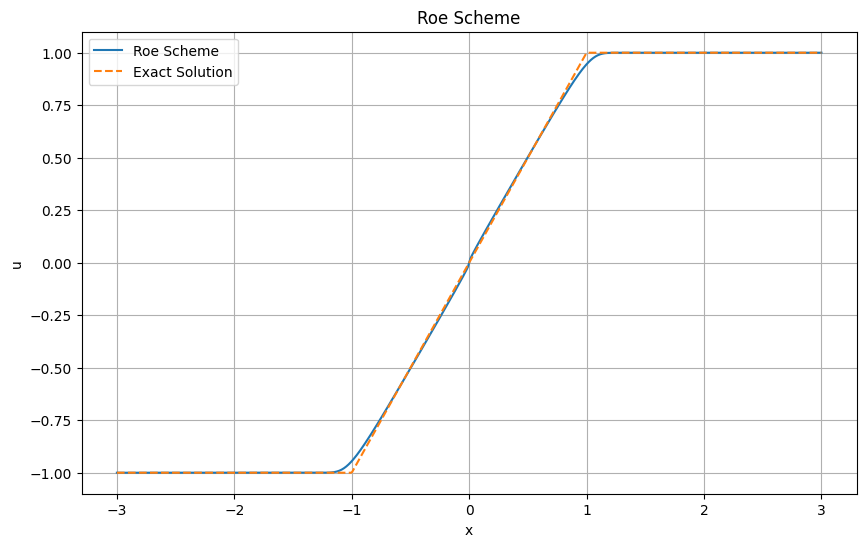

In [22]:
import numpy as np
import matplotlib.pyplot as plt


L = 3.0                          
T = 1.0             
CFL = 0.5

n = 100
tau_n = 1 / (2*n+1)

dx = tau_n / CFL
N = int(2*L / dx)
x = np.linspace(-L, L, N)

dt = CFL * dx
Nt = int(T / dt)

def roe_flux(u, v):
    c = (0.5 * (u + v))
    if c>=0:
        return u**2 /2
    else:
        return v**2 /2

u = np.zeros_like(x)

for i in range(N):
    xl = x[i] - dx/2
    xr = x[i] + dx/2

    if xr <= 0:
        u[i] = -1.0
    elif xl >= 0:
        u[i] = 1.0
    else:
        # x=0
        u[i] = ((0 - xl)*(-1.0) + (xr - 0)*(1.0)) / dx

u_new = np.copy(u)

for n in range(Nt):
    for i in range(1, N-1):
        u_new[i] = u[i] - dt/dx * (roe_flux(u[i], u[i+1]) - roe_flux(u[i-1], u[i]))
    u = np.copy(u_new)

u_exact = np.zeros_like(u)

x0 = 0.0

for i in range(N):

    if x[i] < x0 - T:
        u_exact[i] = -1.0

    elif x[i] > x0 + T:
        u_exact[i] = 1.0

    else:
        u_exact[i] = (x[i] - x0)/T

plt.figure(figsize=(10, 6))
plt.plot(x, u, label='Roe Scheme')
plt.plot(x, u_exact, label='Exact Solution', linestyle='dashed')
plt.xlabel('x')
plt.ylabel('u')
plt.title('Roe Scheme')
plt.legend()
plt.grid()
plt.show()